In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import synergy_dataset as sd
from matplotlib.colors import LogNorm

In [ ]:
studies = pd.read_json("synergy_studies_validation.jsonl", lines=True)
studies_filtered = studies.sort_values("dataset_id").reset_index(drop=True)

recall_files = [
    "recalls_new2_nb.csv",
    "recalls_new2_svm.csv",
    "recalls_old1_nb.csv",
    "recalls_old1_svm.csv",
]
recall_types = ["ASR2 Naive Bayes", "ASR2 SVM", "ASR1.6 Naive Bayes", "ASR1.6 SVM"]
comparison_recall_type = "ASR1.6 Naive Bayes"

In [ ]:
def get_total_relevant(dataset_id):
    if dataset_id in {"Moran_2021_corrected", "Muthu_2021_corrected"}:
        return pd.read_csv(f"../src/datasets/{dataset_id}_shuffled_raw.csv")[
            "label_included"
        ].sum()
    else:
        return sd.Dataset(dataset_id).to_frame()["label_included"].sum()


# Build the dictionary
total_relevant_dict = {
    dataset_id: get_total_relevant(dataset_id)
    for dataset_id in studies_filtered["dataset_id"].unique()
}

In [ ]:
recall_dfs = [pd.read_csv(f) for f in recall_files]

# Add metadata to each DataFrame
for i, df in enumerate(recall_dfs):
    df["dataset_name"] = studies_filtered["dataset_id"].values
    df["optimization"] = recall_types[i]
    df["prior_inclusions"] = studies_filtered["prior_inclusions"].apply(len)
    df["prior_exclusions"] = studies_filtered["prior_exclusions"].apply(len)
    df["simulation_id"] = df.groupby("dataset_name").cumcount() + 1

# Combine recall data
df_all = pd.concat(recall_dfs, ignore_index=True)

# Melt dataframe
df_all_melted = df_all.melt(
    id_vars=["dataset_name", "optimization", "prior_inclusions", "prior_exclusions"],
    var_name="step",
    value_name="recall",
).dropna()

# Convert step to numeric
df_all_melted["step"] = df_all_melted["step"].astype(int)

# Calculate total relevant items
df_all_melted["total_relevant"] = df_all_melted["dataset_name"].map(total_relevant_dict)

# Recall normalization
df_all_melted["relative_recall"] = df_all_melted["recall"] / np.minimum(
    df_all_melted["total_relevant"] - df_all_melted["prior_inclusions"], 100
)

# Recal @ 100


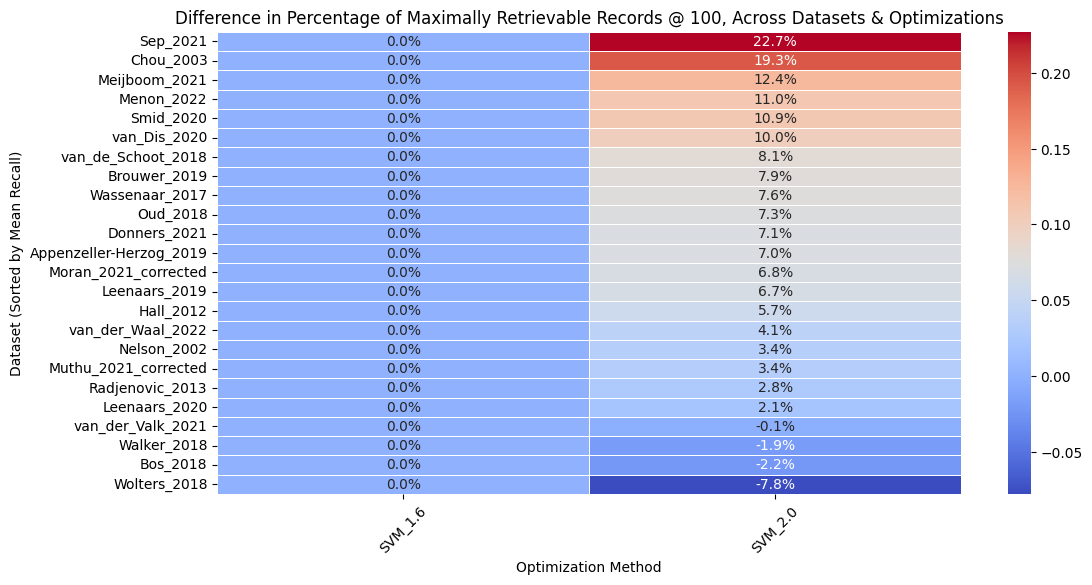

In [ ]:
# Filter data for step 99
df_step_99 = df_all_melted[df_all_melted["step"] == 99]

# Aggregate by mean in case of duplicates
df_step_99 = (
    df_step_99.groupby(["dataset_name", "optimization"])["relative_recall"]
    .mean()
    .reset_index()
)

# Get the relative recall for 'Old1.6' for each dataset
comp_recall = (
    df_step_99[df_step_99["optimization"] == comparison_recall_type]
    .groupby("dataset_name")["relative_recall"]
    .first()
)

# Subtract 'Old1.6' relative recall from all relative recall values
df_step_99["relative_recall_diff"] = df_step_99.apply(
    lambda row: row["relative_recall"] - comp_recall[row["dataset_name"]], axis=1
)

# Compute mean recall per dataset for sorting
dataset_mean = (
    df_step_99.groupby("dataset_name")["relative_recall_diff"]
    .mean()
    .sort_values(ascending=False)
)

# Pivot table for heatmap
heatmap_data = df_step_99.pivot(
    index="dataset_name", columns="optimization", values="relative_recall_diff"
)

# Reorder dataset index based on mean recall
heatmap_data = heatmap_data.loc[dataset_mean.index]

heatmap_data = heatmap_data[recall_types]

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1%", cmap="coolwarm", linewidths=0.5)
plt.title(
    "Difference in Percentage of Maximally Retrievable Records @ 100, Across Datasets & Optimizations"
)
plt.xlabel("Optimization Method")
plt.ylabel("Dataset (Sorted by Mean Recall)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


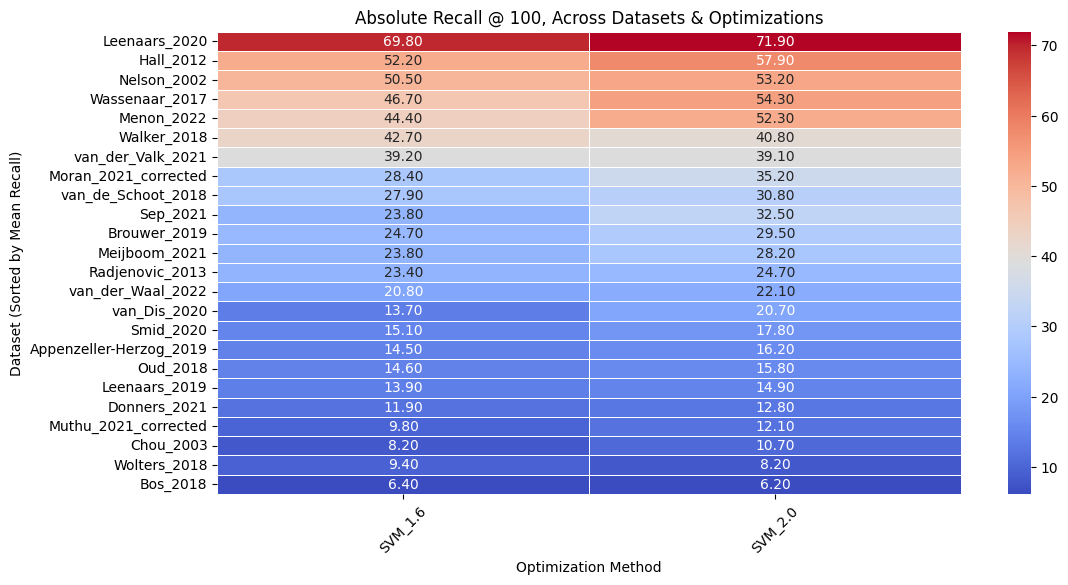

In [ ]:
# Filter data for step 99
df_step_99 = df_all_melted[df_all_melted["step"] == 99]

# Aggregate by mean in case of duplicates
df_step_99 = (
    df_step_99.groupby(["dataset_name", "optimization"])["recall"].mean().reset_index()
)

# Compute mean recall per dataset for sorting
dataset_mean = (
    df_step_99.groupby("dataset_name")["recall"].mean().sort_values(ascending=False)
)

# Pivot table for heatmap
heatmap_data = df_step_99.pivot(
    index="dataset_name", columns="optimization", values="recall"
)

# Reorder dataset index based on mean recall
heatmap_data = heatmap_data.loc[dataset_mean.index]

heatmap_data = heatmap_data[recall_types]

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Absolute Recall @ 100, Across Datasets & Optimizations")
plt.xlabel("Optimization Method")
plt.ylabel("Dataset (Sorted by Mean Recall)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


# Papers Read @ 100%


In [ ]:
df_all_melted["target_recall"] = (
    df_all_melted["total_relevant"] - df_all_melted["prior_inclusions"]
)

df_completion_steps = (
    df_all_melted[df_all_melted["recall"] >= df_all_melted["target_recall"]]
    .groupby(["dataset_name", "optimization"])["step"]
    .min()
    .reset_index()
)

# Pivot table for heatmap
heatmap_data = df_completion_steps.pivot(
    index="dataset_name", columns="optimization", values="step"
)

heatmap_data = heatmap_data[recall_types]
# Order datasets by mean step value for better readability
heatmap_data = heatmap_data.loc[heatmap_data.mean(axis=1).sort_values().index]

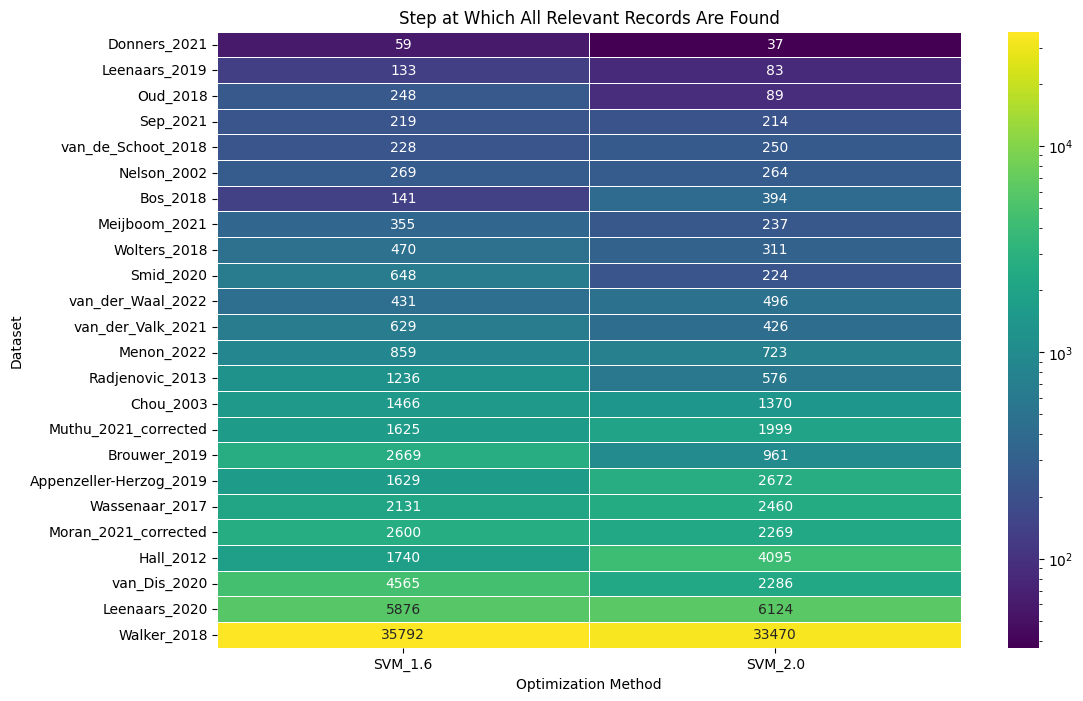

In [13]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data, annot=True, fmt=".0f", cmap="viridis", linewidths=0.5, norm=LogNorm()
)
plt.xlabel("Optimization Method")
plt.ylabel("Dataset")
plt.title("Step at Which All Relevant Records Are Found")
plt.show()


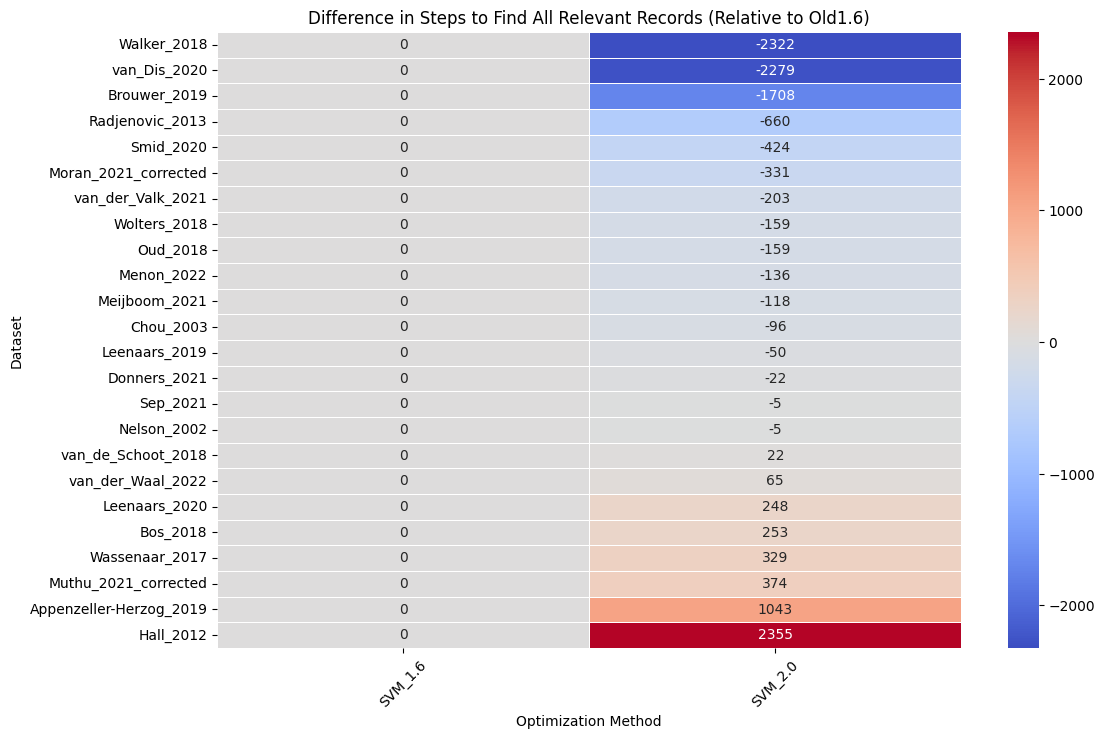

In [14]:
# Subtract "Old1.6" from all other columns
heatmap_data_diff = heatmap_data.sub(heatmap_data[comparison_recall_type], axis=0)

# Order datasets by mean difference for better readability
heatmap_data_diff = heatmap_data_diff.loc[
    heatmap_data_diff.mean(axis=1).sort_values().index
]

heatmap_data_diff = heatmap_data_diff[recall_types]

# Plot heatmap of differences
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data_diff,
    annot=True,
    fmt=".0f",
    cmap="coolwarm",  # Diverging colormap to show positive & negative differences
    linewidths=0.5,
    center=0,  # Center at 0 for better visual contrast
)

plt.xlabel("Optimization Method")
plt.ylabel("Dataset")
plt.title("Difference in Steps to Find All Relevant Records (Relative to Old1.6)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


# Papers Read @ 95%


In [ ]:
# Calculate 95% of relevant records
df_all_melted["threshold_95"] = 0.95 * (
    df_all_melted["total_relevant"] - df_all_melted["prior_inclusions"]
)


# Identify at which step 95% of relevant records are found
def find_95_index(group):
    # Find the step at which cumulative recall reaches 95% of relevant records
    group_sorted = group.sort_values("step")
    group_sorted["cumsum_recall"] = group_sorted["relative_recall"].cumsum()
    threshold_step = group_sorted[
        group_sorted["cumsum_recall"] >= group_sorted["threshold_95"]
    ].iloc[0]["step"]
    return threshold_step


df_95_steps = (
    df_all_melted.groupby(["dataset_name", "optimization"])
    .apply(find_95_index, include_groups=False)
    .reset_index(name="step_95")
)
heatmap_data = df_95_steps.pivot(
    index="dataset_name", columns="optimization", values="step_95"
)

heatmap_data = heatmap_data[recall_types]

# Order datasets by mean step value for better readability
heatmap_data = heatmap_data.loc[heatmap_data.mean(axis=1).sort_values().index]

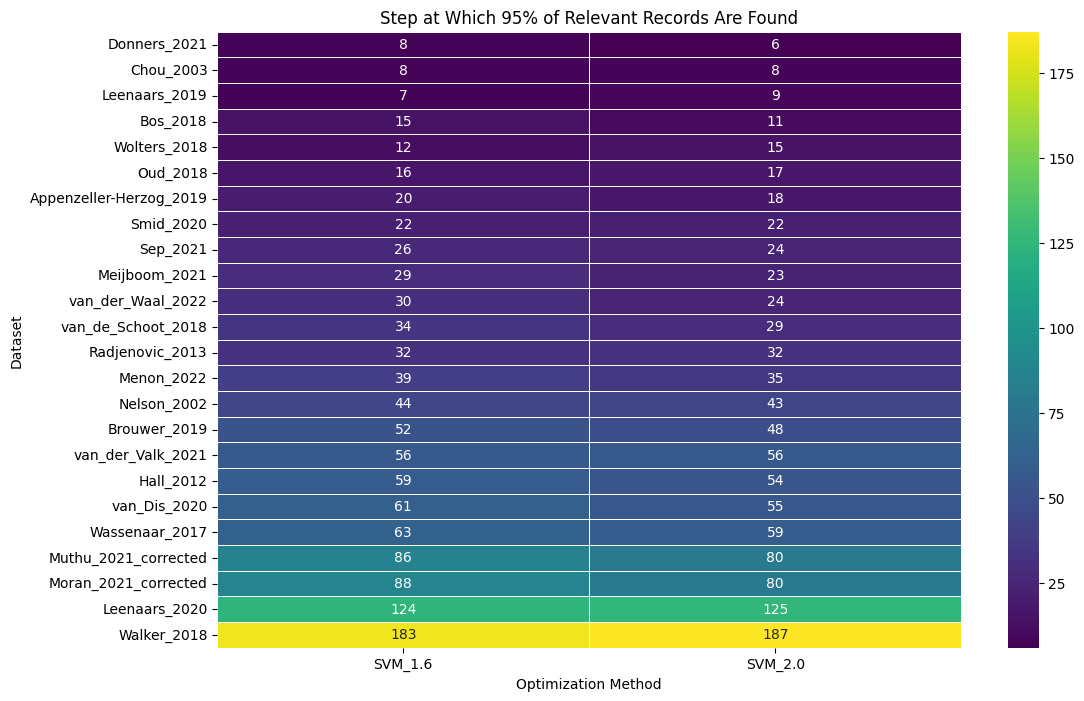

In [16]:
# Visualize with a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap="viridis", fmt=".0f", linewidths=0.5)
plt.xlabel("Optimization Method")
plt.ylabel("Dataset")
plt.title("Step at Which 95% of Relevant Records Are Found")
plt.show()

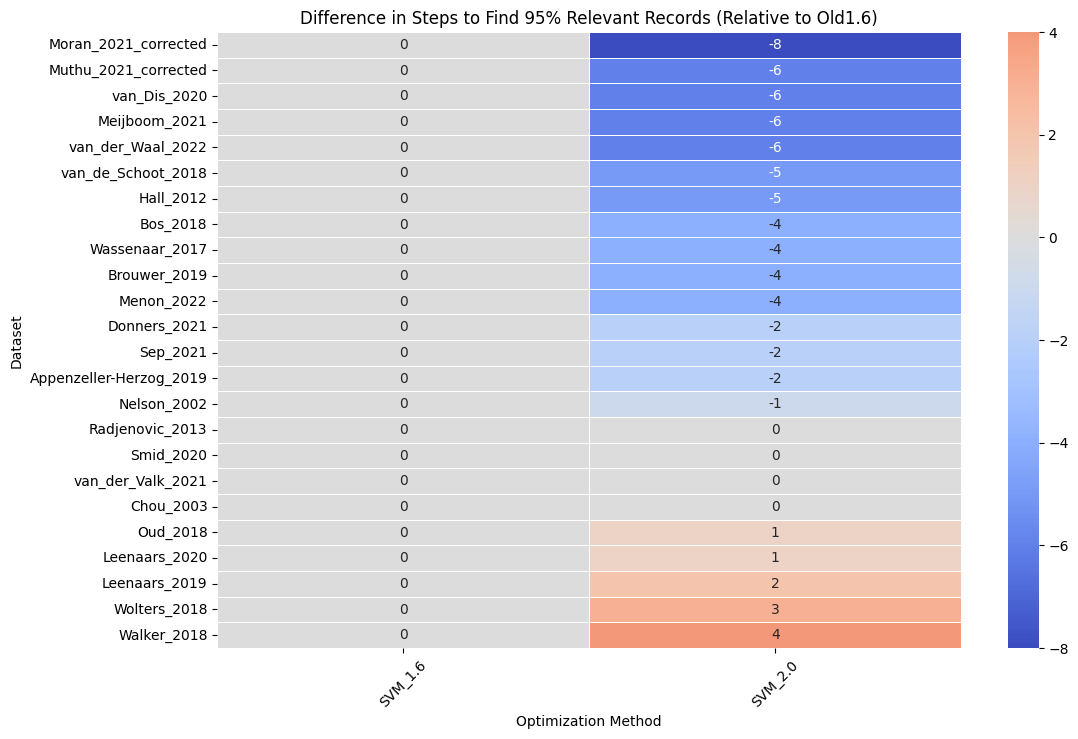

In [18]:
# Subtract "Old1.6" from all other columns
heatmap_data_diff = heatmap_data.sub(heatmap_data[comparison_recall_type], axis=0)

# Order datasets by mean difference for better readability
heatmap_data_diff = heatmap_data_diff.loc[
    heatmap_data_diff.mean(axis=1).sort_values().index
]

heatmap_data_diff = heatmap_data_diff[recall_types]

# Plot heatmap of differences
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data_diff,
    annot=True,
    fmt=".0f",
    cmap="coolwarm",  # Diverging colormap to show positive & negative differences
    linewidths=0.5,
    center=0,  # Center at 0 for better visual contrast
)

plt.xlabel("Optimization Method")
plt.ylabel("Dataset")
plt.title("Difference in Steps to Find 95% Relevant Records (Relative to Old1.6)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()